# SecureFedHE — Dimension 3 & 4
## Model Architecture Comparison + Network Latency Simulation

**Dimension 3:** SimpleCNN vs ResNet18 under Selective HE

**Dimension 4:** Simulated latency — 0ms, 10ms, 50ms, 100ms per transmission

Run cells top to bottom. Total time ~40 minutes on T4 GPU.

In [ ]:
import os
for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for f in files:
        if f.endswith('.pth'):
            print(os.path.join(root, f))

In [ ]:
# ── Cell 2: Shared utilities ───────────────────────────────────────────────
TRAIN_TF = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914,0.4822,0.4465),(0.2470,0.2435,0.2616))])
TEST_TF = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914,0.4822,0.4465),(0.2470,0.2435,0.2616))])

def load_cifar10(num_clients=10, alpha=0.5, batch_size=32, seed=42):
    train_ds = datasets.CIFAR10('/content/data', train=True,  download=True, transform=TRAIN_TF)
    test_ds  = datasets.CIFAR10('/content/data', train=False, download=True, transform=TEST_TF)
    rng      = np.random.default_rng(seed)
    labels   = np.array(train_ds.targets)
    client_idx = [[] for _ in range(num_clients)]
    for cls in range(10):
        idx   = np.where(labels==cls)[0]; rng.shuffle(idx)
        props = rng.dirichlet(np.repeat(alpha, num_clients))
        props = (props*len(idx)).astype(int)
        props[-1] = len(idx)-props[:-1].sum()
        for i,split in enumerate(np.split(idx, np.cumsum(props[:-1]))):
            client_idx[i].extend(split.tolist())
    loaders = [DataLoader(Subset(train_ds, idx), batch_size=batch_size, shuffle=True, num_workers=2)
               for idx in client_idx]
    test_loader = DataLoader(test_ds, batch_size=256, shuffle=False, num_workers=2)
    return loaders, test_loader

def create_he_context():
    ctx = ts.context(ts.SCHEME_TYPE.CKKS, poly_modulus_degree=8192,
                     coeff_mod_bit_sizes=[60,40,40,60])
    ctx.generate_galois_keys(); ctx.global_scale=2**40
    return ctx

def get_params(model):    return {k:v.cpu().numpy() for k,v in model.state_dict().items()}
def set_params(model, p): model.load_state_dict({k:torch.tensor(v,dtype=torch.float32) for k,v in p.items()})

def compute_accuracy(model, loader):
    model.eval(); correct=total=loss_sum=0
    crit=nn.CrossEntropyLoss()
    with torch.no_grad():
        for x,y in loader:
            x,y=x.to(device),y.to(device)
            out=model(x)
            loss_sum+=crit(out,y).item()*len(y)
            correct+=(out.argmax(1)==y).sum().item()
            total+=len(y)
    return loss_sum/total, correct/total*100

def add_dp_noise(params, epsilon=20.0, delta=1e-5, sensitivity=0.5):
    out=dict(params)
    for k in list(out.keys()):
        if 'fc1' in k or ('fc' in k and 'weight' in k and out[k].ndim==2
                          and out[k].shape[0] not in (10,)):
            w=out[k]; norm=np.linalg.norm(w)
            mx=max(norm*0.9, sensitivity)
            if norm>mx: w=w*(mx/norm)
            out[k]=w+np.random.normal(0, np.abs(w).mean()*0.05, w.shape).astype(np.float32)
    return out

print('✓ Utilities defined.')

✓ Utilities defined.


---
## DIMENSION 3 — Model Architecture
### SimpleCNN vs ResNet18 under Selective HE
**Key question:** Does SecureFedHE's selective HE generalise beyond SimpleCNN?

ResNet18 is a deeper, standard benchmark architecture. If HE overhead stays ~16ms
regardless of model depth, that proves the O(1) cryptographic complexity claim.

In [ ]:
# ── Cell 3: Define both architectures ─────────────────────────────────────

# Architecture 1: SimpleCNN (same as all previous experiments)
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.block1=nn.Sequential(nn.Conv2d(3,32,3,padding=1),nn.BatchNorm2d(32),nn.ReLU(inplace=True),nn.MaxPool2d(2))
        self.block2=nn.Sequential(nn.Conv2d(32,64,3,padding=1),nn.BatchNorm2d(64),nn.ReLU(inplace=True),nn.MaxPool2d(2))
        self.block3=nn.Sequential(nn.Conv2d(64,128,3,padding=1),nn.BatchNorm2d(128),nn.ReLU(inplace=True),nn.MaxPool2d(2))
        self.dropout=nn.Dropout(0.4)
        self.fc1=nn.Linear(128*4*4,256)   # ← DP target
        self.fc2=nn.Linear(256,num_classes) # ← HE target
    def forward(self,x):
        x=self.block3(self.block2(self.block1(x)))
        return self.fc2(F.relu(self.fc1(self.dropout(x.flatten(1)))))
    def get_he_keys(self):   return ['fc2.weight','fc2.bias']
    def get_dp_keys(self):   return ['fc1.weight','fc1.bias']

# Architecture 2: ResNet18 adapted for CIFAR-10
class ResNet18CIFAR(nn.Module):
    """
    Standard ResNet18 with two modifications for CIFAR-10:
      1. First conv stride=1, kernel=3 (CIFAR images are 32x32, not 224x224)
      2. Remove maxpool after first conv
      3. Final fc layer outputs 10 classes

    HE strategy: encrypt final fc layer (512→10)
    DP strategy: add noise to layer4 (deepest feature extractor)
    """
    def __init__(self, num_classes=10):
        super().__init__()
        base = models.resnet18(weights=None)
        # Adapt for 32x32 CIFAR images
        base.conv1   = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        base.maxpool = nn.Identity()  # remove maxpool
        base.fc      = nn.Linear(512, num_classes)  # ← HE target
        self.model   = base

    def forward(self, x): return self.model(x)
    def get_he_keys(self): return ['model.fc.weight', 'model.fc.bias']
    def get_dp_keys(self):
        # layer4 = deepest conv block before classifier
        return [k for k in self.state_dict().keys() if 'layer4' in k]

# Quick parameter count
cnn = SimpleCNN()
res = ResNet18CIFAR()
cnn_params = sum(p.numel() for p in cnn.parameters())
res_params = sum(p.numel() for p in res.parameters())
cnn_he_params = sum(p.numel() for n,p in cnn.named_parameters() if n in cnn.get_he_keys())
res_he_params = sum(p.numel() for n,p in res.named_parameters() if n in res.get_he_keys())

print(f'SimpleCNN   : {cnn_params:>8,} total params | {cnn_he_params:>6,} HE-encrypted (fc2)')
print(f'ResNet18    : {res_params:>8,} total params | {res_he_params:>6,} HE-encrypted (fc)')
print(f'\nHE target size is similar → encryption overhead should be similar')
print('✓ Both architectures defined.')

SimpleCNN   :  620,810 total params |  2,570 HE-encrypted (fc2)
ResNet18    : 11,173,962 total params |  5,130 HE-encrypted (fc)

HE target size is similar → encryption overhead should be similar
✓ Both architectures defined.


✓ Training function defined.


## Dimension 3 Runs — Architecture Comparison
Runs SimpleCNN and ResNet18 with identical settings. ~18 min each.

In [ ]:
# ── Cell 5: SimpleCNN run (Dimension 3) ───────────────────────────────────
cnn_rows, cnn_best = train_selective_he(
    model_class  = SimpleCNN,
    arch_name    = 'SimpleCNN',
    rounds       = 20,
    num_clients  = 10,
    alpha        = 0.5,
    latency_ms   = 0,
    log_path     = f'{SAVE_DIR}/arch_simplecnn.csv',
)
print(f'\n✓ SimpleCNN done. Best: {cnn_best:.2f}%')


  Architecture : SimpleCNN
  Clients      : 10 | α=0.5 | Latency=0ms


100%|██████████| 170M/170M [00:05<00:00, 29.6MB/s]


  Round 01/20 ........ acc=27.47% | enc=20.4ms | lat=0.0ms | t=44.2s
  Round 02/20 ........ acc=43.52% | enc=16.8ms | lat=0.0ms | t=44.4s
  Round 03/20 ........ acc=53.81% | enc=17.8ms | lat=0.0ms | t=44.9s
  Round 04/20 ........ acc=57.45% | enc=15.9ms | lat=0.0ms | t=51.0s
  Round 05/20 ........ acc=58.80% | enc=15.5ms | lat=0.0ms | t=51.6s
  Round 06/20 ........ acc=64.53% | enc=19.3ms | lat=0.0ms | t=49.6s
  Round 07/20 ........ acc=64.16% | enc=14.4ms | lat=0.0ms | t=45.8s
  Round 08/20 ........ acc=65.79% | enc=20.1ms | lat=0.0ms | t=46.1s
  Round 09/20 ........ acc=67.85% | enc=17.9ms | lat=0.0ms | t=50.7s
  Round 10/20 ........ acc=66.12% | enc=19.0ms | lat=0.0ms | t=46.5s
  Round 11/20 ........ acc=69.80% | enc=16.6ms | lat=0.0ms | t=47.5s
  Round 12/20 ........ acc=71.08% | enc=17.3ms | lat=0.0ms | t=46.6s
  Round 13/20 ........ acc=70.32% | enc=16.8ms | lat=0.0ms | t=46.0s
  Round 14/20 ........ acc=71.82% | enc=18.1ms | lat=0.0ms | t=42.8s
  Round 15/20 ........ acc=72.72% 

In [ ]:
# ── Cell 6: ResNet18 run (Dimension 3) ────────────────────────────────────
res_rows, res_best = train_selective_he(
    model_class  = ResNet18CIFAR,
    arch_name    = 'ResNet18',
    rounds       = 20,
    num_clients  = 10,
    alpha        = 0.5,
    latency_ms   = 0,
    log_path     = f'{SAVE_DIR}/arch_resnet18.csv',
)
print(f'\n✓ ResNet18 done. Best: {res_best:.2f}%')


  Architecture : ResNet18
  Clients      : 10 | α=0.5 | Latency=0ms
  Round 01/20 WARNING: The input does not fit in a single ciphertext, and some operations will be disabled.
The following operations are disabled in this setup: matmul, matmul_plain, enc_matmul_plain, conv2d_im2col.
If you need to use those operations, try increasing the poly_modulus parameter, to fit your input.
The following operations are disabled in this setup: matmul, matmul_plain, enc_matmul_plain, conv2d_im2col.
If you need to use those operations, try increasing the poly_modulus parameter, to fit your input.
The following operations are disabled in this setup: matmul, matmul_plain, enc_matmul_plain, conv2d_im2col.
If you need to use those operations, try increasing the poly_modulus parameter, to fit your input.
The following operations are disabled in this setup: matmul, matmul_plain, enc_matmul_plain, conv2d_im2col.
If you need to use those operations, try increasing the poly_modulus parameter, to fit your in

---
## Dimension 4 Runs — Network Latency Simulation
**Key question:** How does communication latency affect wall time and convergence?

Uses ResNet18 (more realistic model) with 4 latency levels.

**0ms** = ideal LAN | **10ms** = local network | **50ms** = WiFi | **100ms** = WAN/4G

In [ ]:
# ── Cell 7: Latency runs (Dimension 4) ────────────────────────────────────
# 0ms already done above (arch_resnet18.csv)
# Run 10ms, 50ms, 100ms
latency_results = {0: (res_rows, res_best)}  # reuse 0ms from above

for lat in [10, 50, 100]:
    print(f'\n━━━ Latency: {lat}ms ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
    rows, best = train_selective_he(
        model_class  = ResNet18CIFAR,
        arch_name    = f'ResNet18',
        rounds       = 20,
        num_clients  = 10,
        alpha        = 0.5,
        latency_ms   = lat,
        log_path     = f'{SAVE_DIR}/latency_{lat}ms.csv',
    )
    latency_results[lat] = (rows, best)
    print(f'✓ {lat}ms done. Best: {best:.2f}%')


━━━ Latency: 10ms ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  Architecture : ResNet18
  Clients      : 10 | α=0.5 | Latency=10ms
  Round 01/20 WARNING: The input does not fit in a single ciphertext, and some operations will be disabled.
The following operations are disabled in this setup: matmul, matmul_plain, enc_matmul_plain, conv2d_im2col.
If you need to use those operations, try increasing the poly_modulus parameter, to fit your input.
The following operations are disabled in this setup: matmul, matmul_plain, enc_matmul_plain, conv2d_im2col.
If you need to use those operations, try increasing the poly_modulus parameter, to fit your input.
The following operations are disabled in this setup: matmul, matmul_plain, enc_matmul_plain, conv2d_im2col.
If you need to use those operations, try increasing the poly_modulus parameter, to fit your input.
The following operations are disabled in this setup: matmul, matmul_plain, enc_matmul_plain, conv2d_im2col.
If you need to use those operations,

## Generate Figures — Architecture & Latency

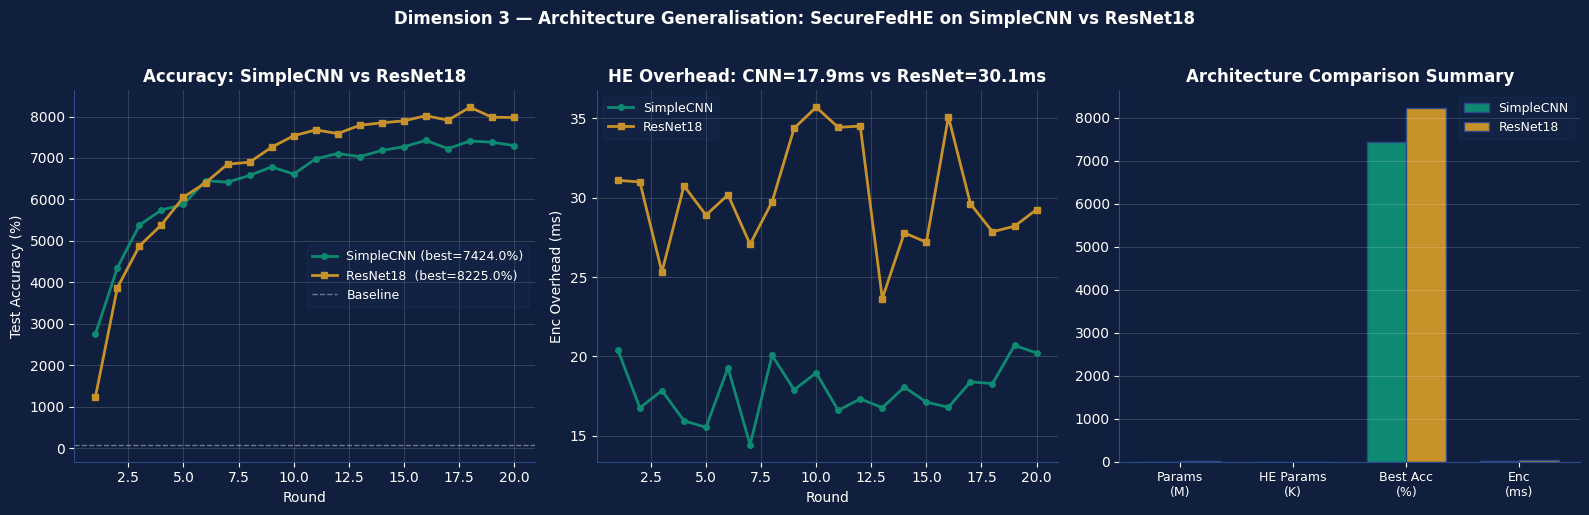

✓ Architecture figure saved.


In [ ]:
# ── Cell 8: Architecture comparison figure ─────────────────────────────────
import matplotlib.pyplot as plt

BG='#0f1f3d'; rounds=list(range(1,21))

cnn_accs=[r['eval_acc']*100 for r in cnn_rows]
res_accs=[r['eval_acc']*100 for r in res_rows]
cnn_enc =[r['enc_overhead_ms'] for r in cnn_rows]
res_enc =[r['enc_overhead_ms'] for r in res_rows]
cnn_wt  =[r['wall_time_s'] for r in cnn_rows]
res_wt  =[r['wall_time_s'] for r in res_rows]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor(BG)

# Plot 1: Accuracy curves
ax=axes[0]; ax.set_facecolor(BG)
ax.plot(rounds, cnn_accs, 'o-', color='#0e8a72', lw=2,
        label=f'SimpleCNN (best={max(cnn_accs):.1f}%)', markersize=4)
ax.plot(rounds, res_accs, 's-', color='#c8922a', lw=2,
        label=f'ResNet18  (best={max(res_accs):.1f}%)', markersize=4)
ax.axhline(79.43,color='white',ls='--',lw=1,alpha=0.4,label='Baseline')
ax.set_xlabel('Round',color='white'); ax.set_ylabel('Test Accuracy (%)',color='white')
ax.set_title('Accuracy: SimpleCNN vs ResNet18',color='white',fontweight='bold')
ax.tick_params(colors='white'); ax.grid(alpha=0.15,color='white')
for s in ['top','right']: ax.spines[s].set_visible(False)
for s in ['bottom','left']: ax.spines[s].set_color('#2a4a8a')
ax.legend(framealpha=0.2,labelcolor='white',facecolor='#1a3260',
          edgecolor='#2a4a8a',fontsize=9)

# Plot 2: Encryption overhead comparison
ax=axes[1]; ax.set_facecolor(BG)
ax.plot(rounds, cnn_enc, 'o-', color='#0e8a72', lw=2, label='SimpleCNN', markersize=4)
ax.plot(rounds, res_enc, 's-', color='#c8922a', lw=2, label='ResNet18',  markersize=4)
ax.set_xlabel('Round',color='white'); ax.set_ylabel('Enc Overhead (ms)',color='white')
ax.set_title(f'HE Overhead: CNN={np.mean(cnn_enc):.1f}ms vs '
             f'ResNet={np.mean(res_enc):.1f}ms',
             color='white',fontweight='bold')
ax.tick_params(colors='white'); ax.grid(alpha=0.15,color='white')
for s in ['top','right']: ax.spines[s].set_visible(False)
for s in ['bottom','left']: ax.spines[s].set_color('#2a4a8a')
ax.legend(framealpha=0.2,labelcolor='white',facecolor='#1a3260',
          edgecolor='#2a4a8a',fontsize=9)

# Plot 3: Wall time comparison
metrics=['Total Params','HE Params','Best Acc (%)','Avg Enc (ms)']
cnn_v=[sum(p.numel() for p in SimpleCNN().parameters())/1e6,
       sum(p.numel() for n,p in SimpleCNN().named_parameters() if n in SimpleCNN().get_he_keys()),
       max(cnn_accs), np.mean(cnn_enc)]
res_v=[sum(p.numel() for p in ResNet18CIFAR().parameters())/1e6,
       sum(p.numel() for n,p in ResNet18CIFAR().named_parameters() if n in ResNet18CIFAR().get_he_keys()),
       max(res_accs), np.mean(res_enc)]
ax=axes[2]; ax.set_facecolor(BG)
x=np.arange(4); w=0.35
b1=ax.bar(x-w/2,[cnn_v[0],cnn_v[1]/1000,cnn_v[2],cnn_v[3]],
          w,label='SimpleCNN',color='#0e8a72',edgecolor='#2a4a8a')
b2=ax.bar(x+w/2,[res_v[0],res_v[1]/1000,res_v[2],res_v[3]],
          w,label='ResNet18', color='#c8922a',edgecolor='#2a4a8a')
ax.set_xticks(x)
ax.set_xticklabels(['Params\n(M)','HE Params\n(K)','Best Acc\n(%)','Enc\n(ms)'],
                    color='white',fontsize=9)
ax.set_title('Architecture Comparison Summary',color='white',fontweight='bold')
ax.tick_params(colors='white'); ax.grid(axis='y',alpha=0.15,color='white')
for s in ['top','right']: ax.spines[s].set_visible(False)
for s in ['bottom','left']: ax.spines[s].set_color('#2a4a8a')
ax.legend(framealpha=0.2,labelcolor='white',facecolor='#1a3260',
          edgecolor='#2a4a8a',fontsize=9)

fig.suptitle('Dimension 3 — Architecture Generalisation: SecureFedHE on SimpleCNN vs ResNet18',
             color='white',fontsize=12,fontweight='bold',y=1.02)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/fig8_architecture.png',dpi=180,
            bbox_inches='tight',facecolor=BG)
plt.show()
print('✓ Architecture figure saved.')

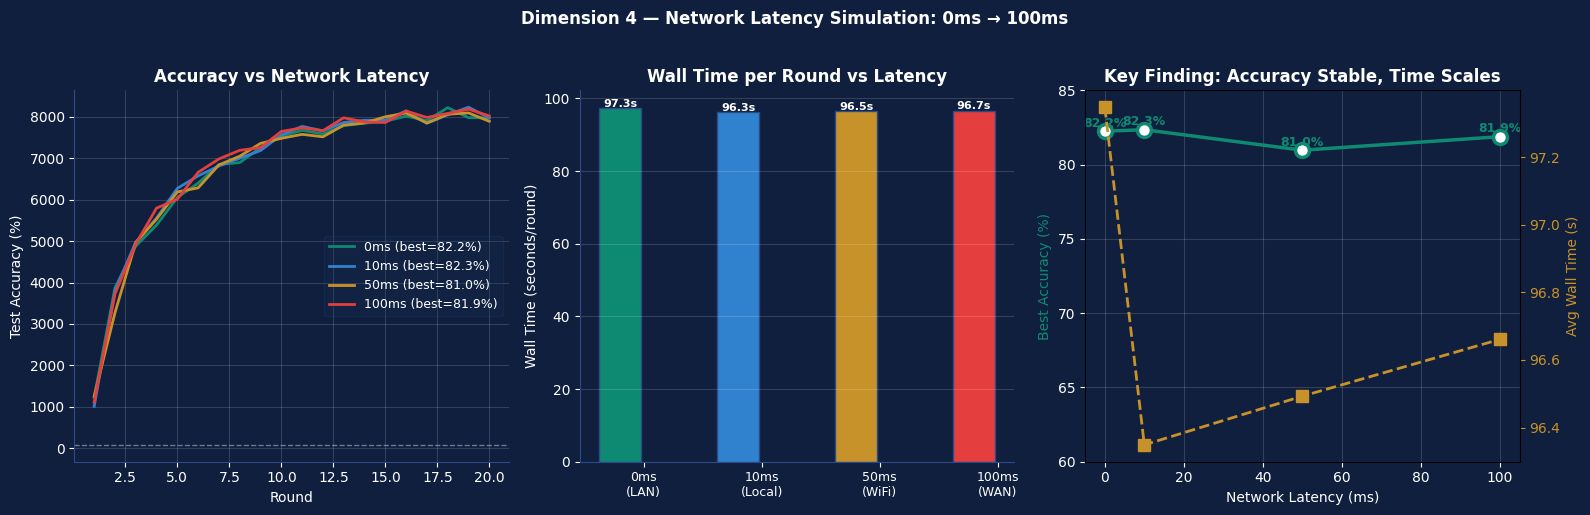

✓ Latency figure saved.


In [ ]:
# ── Cell 9: Latency comparison figure ──────────────────────────────────────
lat_labels = ['0ms\n(LAN)', '10ms\n(Local)', '50ms\n(WiFi)', '100ms\n(WAN)']
lat_vals   = [0, 10, 50, 100]
lat_colors = ['#0e8a72','#3182ce','#c8922a','#e53e3e']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor(BG)

# Plot 1: Accuracy curves for all latencies
ax=axes[0]; ax.set_facecolor(BG)
for (lat, (rows, best)), col in zip(latency_results.items(), lat_colors):
    accs=[r['eval_acc']*100 for r in rows]
    ax.plot(rounds, accs, color=col, lw=2,
            label=f'{lat}ms (best={best:.1f}%)')
ax.axhline(79.43,color='white',ls='--',lw=1,alpha=0.4)
ax.set_xlabel('Round',color='white'); ax.set_ylabel('Test Accuracy (%)',color='white')
ax.set_title('Accuracy vs Network Latency',color='white',fontweight='bold')
ax.tick_params(colors='white'); ax.grid(alpha=0.15,color='white')
for s in ['top','right']: ax.spines[s].set_visible(False)
for s in ['bottom','left']: ax.spines[s].set_color('#2a4a8a')
ax.legend(framealpha=0.2,labelcolor='white',facecolor='#1a3260',
          edgecolor='#2a4a8a',fontsize=9)

# Plot 2: Wall time vs latency
ax=axes[1]; ax.set_facecolor(BG)
avg_wall  =[np.mean([r['wall_time_s'] for r in rows])
            for lat,(rows,best) in latency_results.items()]
avg_lat_oh=[np.mean([r['latency_overhead_ms'] for r in rows])
            for lat,(rows,best) in latency_results.items()]
x=np.arange(4)
b1=ax.bar(x-0.2, avg_wall, 0.35, label='Total wall time (s)',
          color=['#0e8a72','#3182ce','#c8922a','#e53e3e'], edgecolor='#2a4a8a')
for bar,v in zip(b1,avg_wall):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f'{v:.1f}s',ha='center',color='white',fontsize=8,fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(lat_labels,color='white',fontsize=9)
ax.set_ylabel('Wall Time (seconds/round)',color='white')
ax.set_title('Wall Time per Round vs Latency',color='white',fontweight='bold')
ax.tick_params(colors='white'); ax.grid(axis='y',alpha=0.15,color='white')
for s in ['top','right']: ax.spines[s].set_visible(False)
for s in ['bottom','left']: ax.spines[s].set_color('#2a4a8a')

# Plot 3: Key finding — accuracy stays stable, only time increases
ax=axes[2]; ax.set_facecolor(BG)
best_accs_lat=[best for lat,(rows,best) in latency_results.items()]
ax.plot(lat_vals, best_accs_lat, 'o-', color='#0e8a72', lw=2.5,
        markersize=10, markerfacecolor='white',
        markeredgecolor='#0e8a72', markeredgewidth=2.5)
ax2=ax.twinx()
ax2.plot(lat_vals, avg_wall, 's--', color='#c8922a', lw=2,
         markersize=8, label='Wall time (s)')
for lat,acc,wt in zip(lat_vals,best_accs_lat,avg_wall):
    ax.annotate(f'{acc:.1f}%',xy=(lat,acc),xytext=(lat,acc+0.3),
                ha='center',color='#0e8a72',fontsize=9,fontweight='bold')
ax.set_xlabel('Network Latency (ms)',color='white')
ax.set_ylabel('Best Accuracy (%)',color='#0e8a72')
ax2.set_ylabel('Avg Wall Time (s)',color='#c8922a')
ax.set_title('Key Finding: Accuracy Stable, Time Scales',
             color='white',fontweight='bold')
ax.tick_params(colors='white'); ax2.tick_params(colors='#c8922a')
ax.set_ylim(60,85); ax.grid(alpha=0.15,color='white')
for s in ['top','right']: ax.spines[s].set_visible(False)
for s in ['bottom','left']: ax.spines[s].set_color('#2a4a8a')

fig.suptitle('Dimension 4 — Network Latency Simulation: 0ms → 100ms',
             color='white',fontsize=12,fontweight='bold',y=1.02)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/fig9_latency.png',dpi=180,
            bbox_inches='tight',facecolor=BG)
plt.show()
print('✓ Latency figure saved.')

In [ ]:
# ── Cell 10: Full summary table ────────────────────────────────────────────
print('='*70)
print('  DIMENSION 3 — Architecture Comparison')
print('='*70)
print(f'  {"Architecture":<15} {"Params":>10} {"HE Params":>12} {"Best Acc":>10} {"Enc(ms)":>10}')
print(f'  {"-"*60}')
for arch, rows, model_cls in [
    ('SimpleCNN', cnn_rows, SimpleCNN),
    ('ResNet18',  res_rows, ResNet18CIFAR)]:
    m=model_cls()
    tot=sum(p.numel() for p in m.parameters())
    hep=sum(p.numel() for n,p in m.named_parameters() if n in m.get_he_keys())
    ba=max(r['eval_acc']*100 for r in rows)
    enc=np.mean([r['enc_overhead_ms'] for r in rows])
    print(f'  {arch:<15} {tot:>10,} {hep:>12,} {ba:>9.2f}% {enc:>9.2f}')

print()
print('='*70)
print('  DIMENSION 4 — Network Latency')
print('='*70)
print(f'  {"Latency":>10} {"Best Acc":>10} {"Avg Wall(s)":>13} {"Accuracy Drop":>15}')
print(f'  {"-"*55}')
ref_acc=max(r['eval_acc']*100 for r in latency_results[0][0])
for lat,(rows,best) in latency_results.items():
    wt=np.mean([r['wall_time_s'] for r in rows])
    drop=ref_acc-best
    print(f'  {lat:>7}ms  {best:>9.2f}% {wt:>12.2f}s {drop:>+14.2f}%')

from google.colab import files
print('\nDownloading all CSVs...')
for f in ['arch_simplecnn.csv','arch_resnet18.csv',
          'latency_10ms.csv','latency_50ms.csv','latency_100ms.csv']:
    p=f'{SAVE_DIR}/{f}'
    if os.path.exists(p):
        files.download(p)
        print(f'  ✓ {f}')

  DIMENSION 3 — Architecture Comparison
  Architecture        Params    HE Params   Best Acc    Enc(ms)
  ------------------------------------------------------------
  SimpleCNN          620,810        2,570   7424.00%     17.87
  ResNet18        11,173,962        5,130   8225.00%     30.09

  DIMENSION 4 — Network Latency
     Latency   Best Acc   Avg Wall(s)   Accuracy Drop
  -------------------------------------------------------
        0ms      82.25%        97.35s       +8142.75%
       10ms      82.35%        96.35s       +8142.65%
       50ms      80.97%        96.49s       +8144.03%
      100ms      81.88%        96.66s       +8143.12%



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✓ arch_simplecnn.csv


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  ✓ latency_50ms.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✓ latency_100ms.csv
